# Notebook: 02 Class Annotation Exploration
### Purpose: This notebook provides utilities for exploring masks, overlays, classes, and bounding boxes

#### Config and Setup

In [1]:
import os
import random
import sys
from pathlib import Path

from dotenv import load_dotenv

load_dotenv()
_start = Path(os.getenv("PROJECT_ROOT") or Path.cwd()).resolve()
root = next(p for p in [_start, *_start.parents] if (p / "config.yaml").exists())
sys.path[:0] = [str(root), str(root / "src")]

from src.utils.config import Config
from src.utils.helpers import init_notebook

config = Config.load(root = root)
init_notebook(config.train.seed)



auto_adjust disabled
=== init_notebook ===
Done


In [2]:
import os
import sys

from src.data.annotations import get_unique_classes, load_json_annotations
from src.exploration.class_explorer import *
from src.utils.config import Config
from src.utils.helpers import init_notebook, p

config = Config.load(root = root)
init_notebook(config.train.seed)


auto_adjust disabled
=== init_notebook ===
Done


In [3]:
annotations_path = config.paths.annotations

entries = load_json_annotations(annotations_path)
unique_classes = get_unique_classes(entries)

p("Loaded annotation entries", len(entries))
p("Unique annotation classes", unique_classes)


Loaded annotation entries: 150
Unique annotation classes: 2 items
  0: group_of_trees
  1: individual_tree


In [4]:
sample_entries = random.sample(entries, config.train.seed)
entry = sample_entries[0]
p("Classes found in entry", count_classes(entry))
# p("Number of classes found", class_distribution(entry))


Classes found in entry: 2 keys
  individual_tree: 83
  group_of_trees: 0


=== show_single_class ===


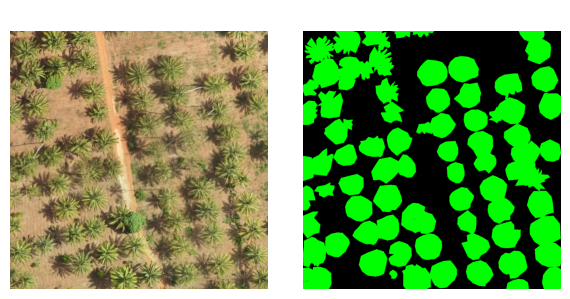

=== show_single_class ===


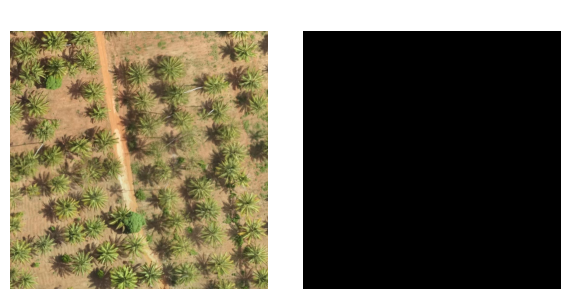

=== show_all_classes ===


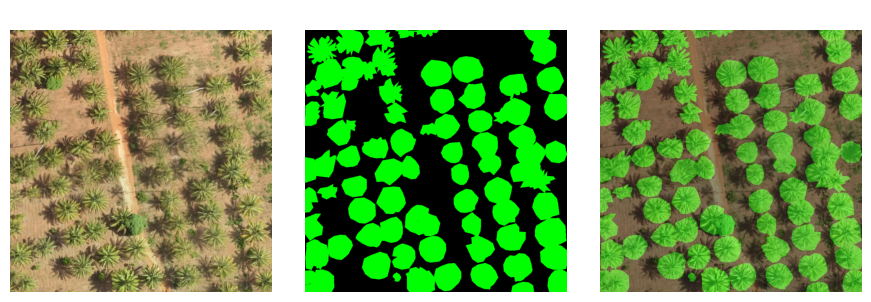

=== show_per_class ===


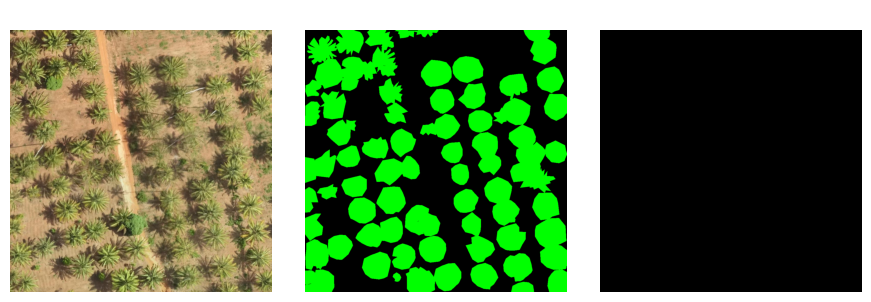

=== show_overlay_all ===


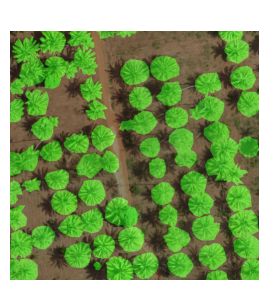

=== show_overlay_by_class ===


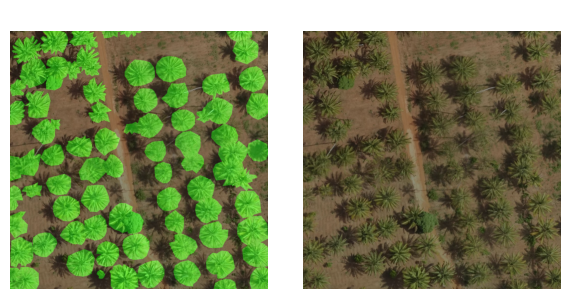

In [5]:
t("show_single_class")
show_single_class(config, entry, "individual_tree")

t("show_single_class")
show_single_class(config, entry, "group_of_trees")

t("show_all_classes")
show_all_classes(config, entry)

t("show_per_class")
show_per_class(config, entry)

t("show_overlay_all")
show_overlay_all(config, entry)

t("show_overlay_by_class")
show_overlay_by_class(config, entry)


#### Explore Masks Per Class

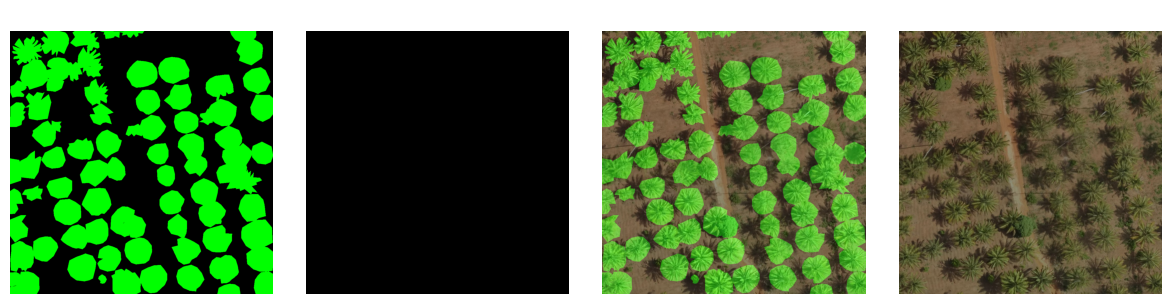

In [6]:
explore_image(config, entry)


#### Color Mask and Overlay

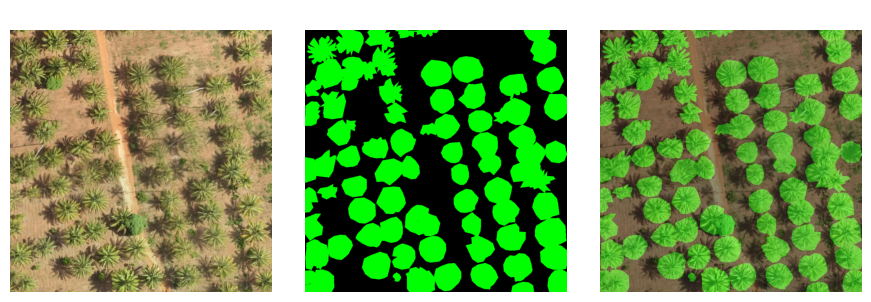

In [7]:
explore_color_overlay(config, entry)


#### Bounding Box Exploration

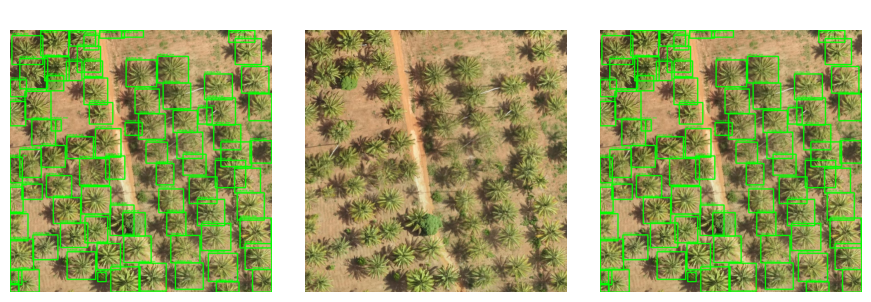

In [8]:
explore_bboxes(config, entry)


#### Dataset-wide Report

Class counts: 2 keys
  individual_tree: 7926
  group_of_trees: 860
Images containing both classes:: 34

=== Image: 10cm_train_35.tif ===


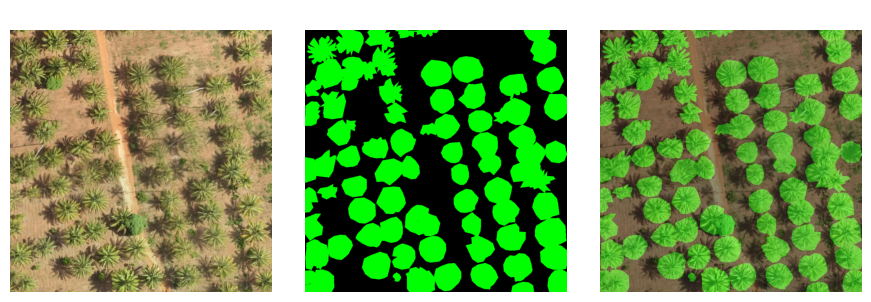

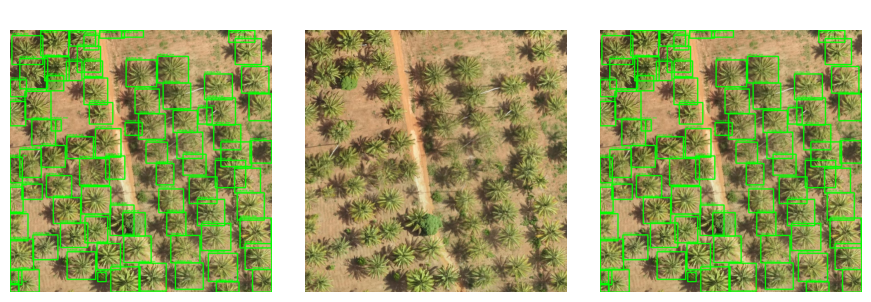

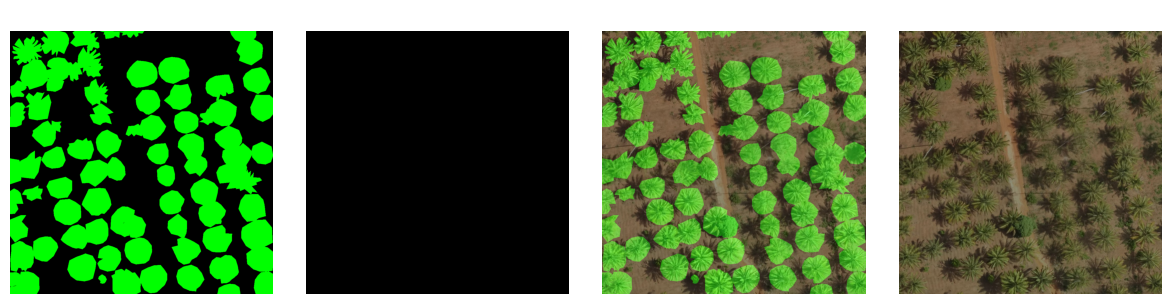



=== Image: 10cm_train_15.tif ===


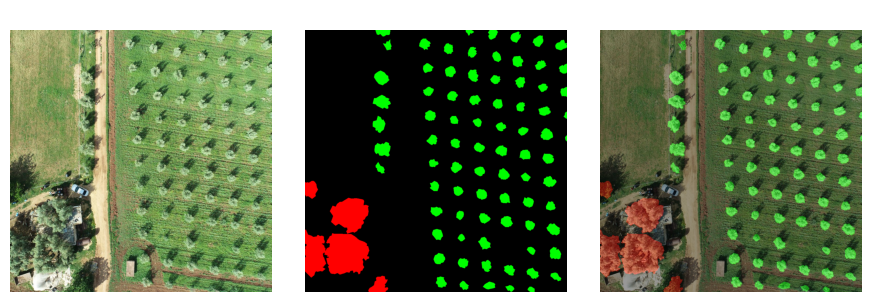

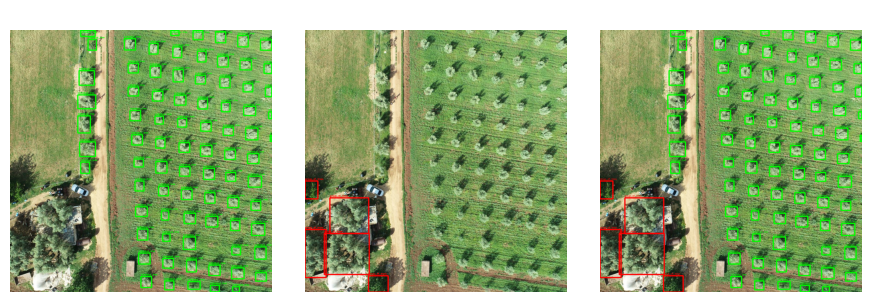

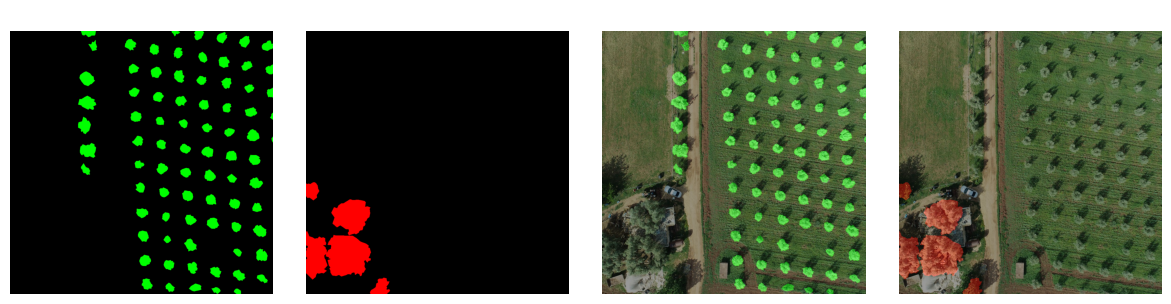



=== Image: 20cm_train_71.tif ===


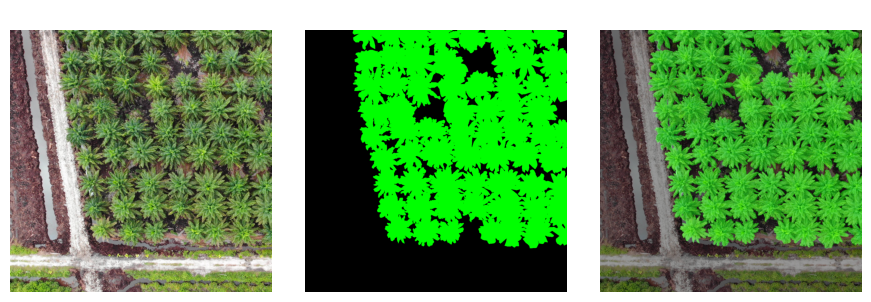

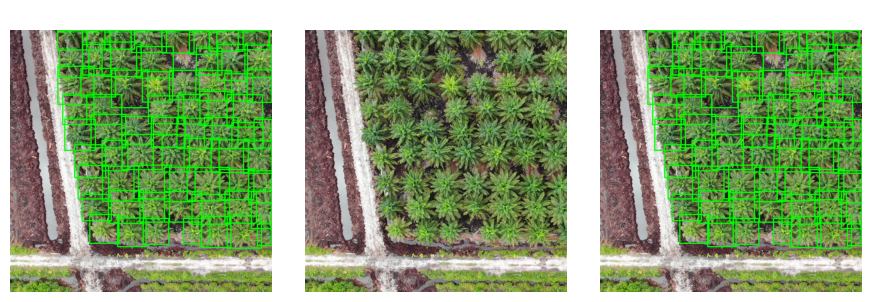

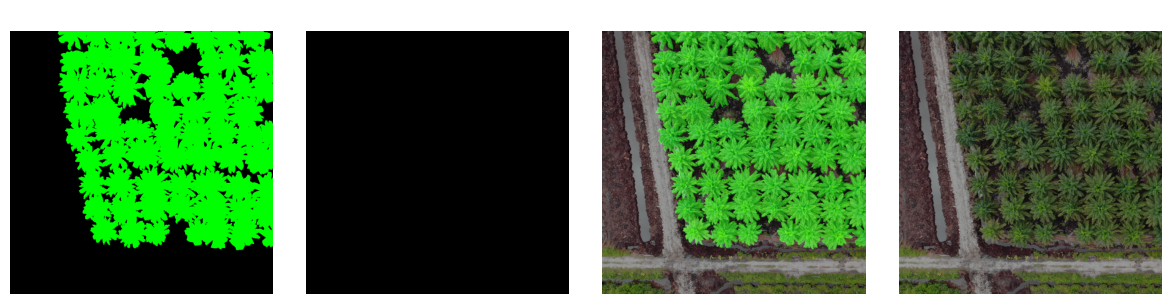

In [9]:
dataset_report(config, sample_entries)
